# Notebook 17 — Tiny Self-Supervised Model Demo
Goal: Understand the **steps** involved in training a foundation-model-like system without needing large data or GPUs.

This notebook does **not** build a real foundation model. Instead, it demonstrates the core training pattern on a tiny toy example:

`raw inputs → self-supervised objective → encoder → embedding space → downstream task`

We will train a small neural network to predict whether two augmented views came from the same original item. This is a simplified version of the representation-learning idea behind many foundation models.

## Section 1 — Import Libraries

In [1]:
# If needed:
# pip install torch scikit-learn matplotlib numpy pandas

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

## Section 2 — High-Level Idea
A real foundation model is usually trained with a **self-supervised objective** such as:

- masked token prediction
- masked patch prediction
- contrastive learning
- next-token prediction

Here we will use a tiny contrastive-style idea:

1. start with some original examples
2. make two noisy versions of each example
3. train a model so embeddings from the same source are close
4. embeddings from different sources should be less similar

This is only a toy demonstration, but the workflow is real.

## Section 3 — Create Tiny Toy Data

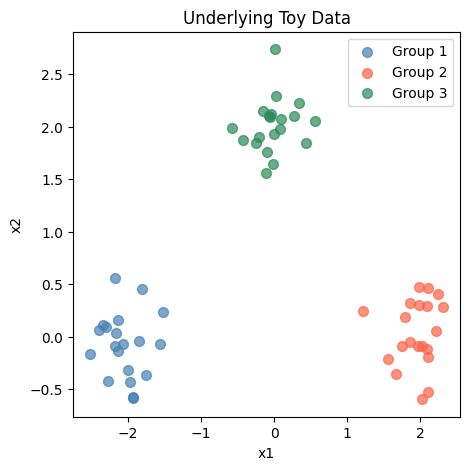

(60, 2)

In [2]:
np.random.seed(42)

# Three underlying groups — store labels so we can colour visualisations later
group1 = np.random.normal(loc=[-2, 0], scale=0.3, size=(20, 2))
group2 = np.random.normal(loc=[ 2, 0], scale=0.3, size=(20, 2))
group3 = np.random.normal(loc=[ 0, 2], scale=0.3, size=(20, 2))

base_data = np.vstack([group1, group2, group3])
labels    = np.array([0]*20 + [1]*20 + [2]*20)

colors      = ["steelblue", "tomato", "seagreen"]
group_names = ["Group 1", "Group 2", "Group 3"]

plt.figure(figsize=(5, 5))
for g in range(3):
    mask = labels == g
    plt.scatter(base_data[mask, 0], base_data[mask, 1],
                c=colors[g], label=group_names[g], alpha=0.7, s=50)
plt.title("Underlying Toy Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

base_data.shape

## Section 4 — Create Two Augmented Views
In self-supervised learning, we often create different views of the same item.
Here, each view is just the original point plus a little random noise.

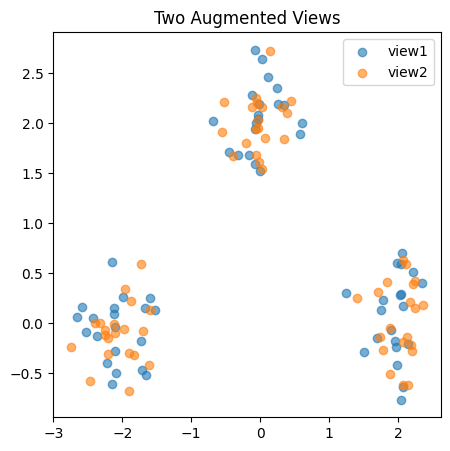

In [3]:
def augment(x, noise_scale=0.15):
    noise = np.random.normal(scale=noise_scale, size=x.shape)
    return x + noise

view1 = augment(base_data)
view2 = augment(base_data)

plt.figure(figsize=(5, 5))
plt.scatter(view1[:,0], view1[:,1], label="view1", alpha=0.6)
plt.scatter(view2[:,0], view2[:,1], label="view2", alpha=0.6)
plt.legend()
plt.title("Two Augmented Views")
plt.show()

## Section 5 — Build Positive and Negative Pairs
We need a training signal.

- Positive pair: two views of the same original point
- Negative pair: views from different original points

We will train a small model to tell whether a pair is positive or negative.

In [4]:
# Positive pairs
positive_pairs = [(view1[i], view2[i], 1) for i in range(len(base_data))]

# Negative pairs
rng = np.random.default_rng(42)
negative_pairs = []
for i in range(len(base_data)):
    j = rng.integers(0, len(base_data))
    while j == i:
        j = rng.integers(0, len(base_data))
    negative_pairs.append((view1[i], view2[j], 0))

pairs = positive_pairs + negative_pairs
rng.shuffle(pairs)

X_left = np.array([p[0] for p in pairs], dtype=np.float32)
X_right = np.array([p[1] for p in pairs], dtype=np.float32)
y = np.array([p[2] for p in pairs], dtype=np.float32)

X_left.shape, X_right.shape, y.shape

((120, 2), (120, 2), (120,))

## Section 6 — Define a Tiny Encoder
This encoder turns each input into an embedding vector.

In a real foundation model, the encoder might be:

- a transformer
- a vision transformer
- a protein language model

Here it is just a tiny MLP.

In [5]:
class TinyEncoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, embedding_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, x):
        return self.net(x)


class PairClassifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.net[-1].out_features   # read embedding_dim from the encoder
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim * 2),
            nn.ReLU(),
            nn.Linear(emb_dim * 2, 1)
        )

    def forward(self, x1, x2):
        z1 = self.encoder(x1)
        z2 = self.encoder(x2)
        combined = torch.cat([z1, z2], dim=1)
        logits = self.classifier(combined)
        return logits, z1, z2


encoder = TinyEncoder()
model   = PairClassifier(encoder)
model

PairClassifier(
  (encoder): TinyEncoder(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=8, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

## Section 7 — Convert Data to Tensors

In [6]:
X_left_t = torch.tensor(X_left)
X_right_t = torch.tensor(X_right)
y_t = torch.tensor(y).unsqueeze(1)

X_left_t.shape, y_t.shape

(torch.Size([120, 2]), torch.Size([120, 1]))

## Section 8 — Train the Model
We use a binary objective: predict whether two views come from the same source.

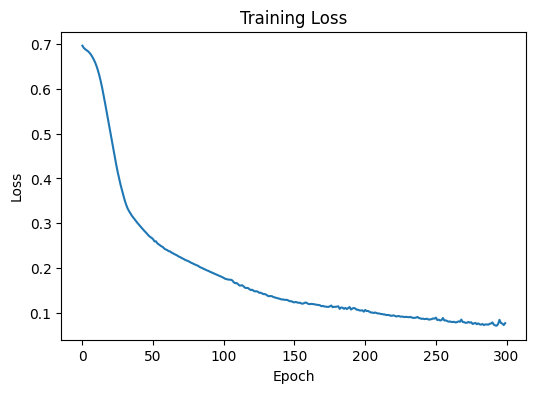

0.07639767974615097

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []

for epoch in range(300):
    optimizer.zero_grad()
    logits, _, _ = model(X_left_t, X_right_t)
    loss = criterion(logits, y_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

losses[-1]

## Section 9 — Extract Learned Embeddings
Now we use the trained encoder by itself.
This is the key idea in applied foundation-model workflows:

- train encoder with a self-supervised objective
- discard the training head
- keep the encoder
- use embeddings downstream

In [8]:
with torch.no_grad():
    learned_embeddings = encoder(torch.tensor(base_data, dtype=torch.float32)).numpy()

learned_embeddings.shape

(60, 8)

## Section 10 — Visualise the Embedding Space

We plot the raw input space and the learned embedding space side by side, coloured by group.

The encoder was trained with **no group labels** — only augmentation pairs. If the embeddings form cleaner clusters than the raw data, the encoder has learned useful structure from the self-supervised objective alone.

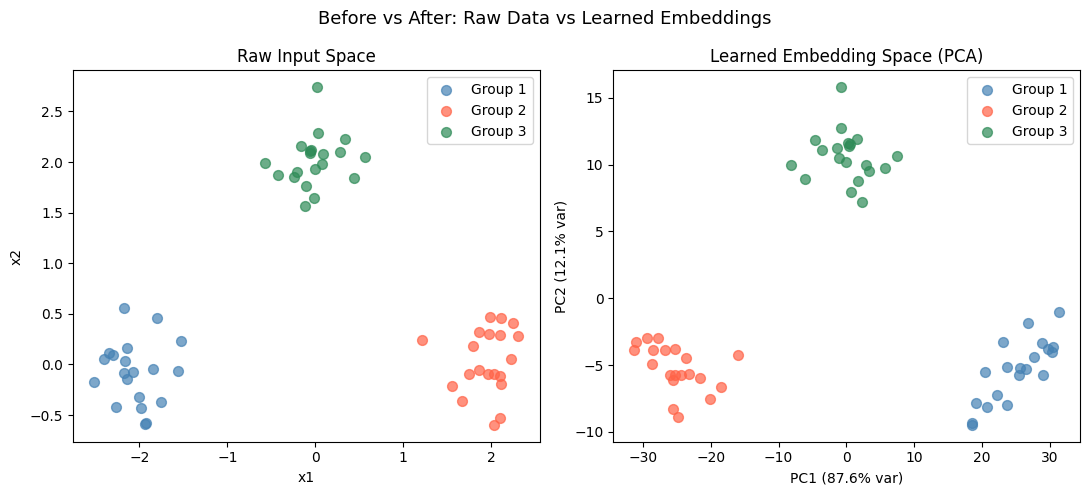

In [9]:
pca = PCA(n_components=2)
coords = pca.fit_transform(learned_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: raw 2D input space
for g in range(3):
    mask = labels == g
    axes[0].scatter(base_data[mask, 0], base_data[mask, 1],
                    c=colors[g], label=group_names[g], alpha=0.7, s=50)
axes[0].set_title("Raw Input Space")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend()

# Right: learned embedding space (PCA to 2D)
for g in range(3):
    mask = labels == g
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    c=colors[g], label=group_names[g], alpha=0.7, s=50)
axes[1].set_title("Learned Embedding Space (PCA)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axes[1].legend()

plt.suptitle("Before vs After: Raw Data vs Learned Embeddings", fontsize=13)
plt.tight_layout()
plt.show()

## Section 11 — Check Embedding Similarity

A good encoder should produce embeddings where points from the **same group** are more similar to each other than points from **different groups** — even though group labels were never used during training.

In [10]:
sim_matrix = cosine_similarity(learned_embeddings)

intra_sims, inter_sims = [], []
for i in range(len(base_data)):
    for j in range(i + 1, len(base_data)):
        if labels[i] == labels[j]:
            intra_sims.append(sim_matrix[i, j])
        else:
            inter_sims.append(sim_matrix[i, j])

print(f"Mean intra-group cosine similarity:  {np.mean(intra_sims):.3f}")
print(f"Mean inter-group cosine similarity:  {np.mean(inter_sims):.3f}")
print()
print("A well-trained encoder shows higher intra-group than inter-group similarity.")

Mean intra-group cosine similarity:  0.978
Mean inter-group cosine similarity:  -0.221

A well-trained encoder shows higher intra-group than inter-group similarity.


## Section 12 — Downstream Task: Classify with Frozen Embeddings

This is the key payoff of self-supervised pretraining: the encoder was trained with **no labels**, but its embeddings can now be used for a **labelled downstream task** with a simple linear classifier.

This mirrors the real foundation model workflow: pretrain on large unlabelled data → freeze the encoder → add a small head for your specific task.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Downstream classifier on frozen embeddings (no encoder fine-tuning)
clf_emb = LogisticRegression(max_iter=500, random_state=42)
scores_emb = cross_val_score(clf_emb, learned_embeddings, labels, cv=5)

# Baseline: same classifier on raw 2D inputs
clf_raw = LogisticRegression(max_iter=500, random_state=42)
scores_raw = cross_val_score(clf_raw, base_data, labels, cv=5)

print(f"Raw input accuracy (5-fold CV):        {scores_raw.mean():.2f} ± {scores_raw.std():.2f}")
print(f"Frozen embedding accuracy (5-fold CV): {scores_emb.mean():.2f} ± {scores_emb.std():.2f}")
print()
print("The encoder learned group structure from augmentation pairs alone —")
print("group labels were only introduced here, at the downstream step.")

## Section 13 — What This Corresponds To in a Real Foundation Model
This tiny demo maps onto real workflows like this:

| Toy notebook step | Real foundation model analogue |
|---|---|
| small MLP encoder | transformer / ViT / protein language model |
| noisy augmented views | text masking / image augmentation / patch masking |
| pair classification objective | contrastive / masked / self-supervised loss |
| learned embeddings | pretrained representation space |
| frozen encoder + linear classifier | fine-tuning / probing a pretrained model |

The notebook is not building a real foundation model, but it demonstrates the core training logic.

## Section 14 — Exercises

1. Change the embedding dimension from 8 to 4 or 16 and retrain.
2. Increase the augmentation noise and observe the effect on training loss and embedding clusters.
3. Reduce the number of training epochs and compare the before/after PCA plots.
4. Try adding a fourth data group and see whether the encoder still separates them.
5. Replace the pair-classification objective with a different toy objective (e.g., predict which group a point belongs to) and compare the learned embeddings.

## Skills Gained
- understanding the training *idea* behind foundation models
- seeing how self-supervised learning creates structure without labels
- separating encoder training from downstream use
- comparing raw input space vs learned embedding space visually
- evaluating embedding quality with intra- vs inter-group similarity
- applying a frozen pretrained encoder to a labelled downstream task

After this notebook, the earlier multimodal notebooks should make more intuitive sense: they use pretrained encoders that were trained in a much larger version of this general pattern.